# QF 627 Programming and Computational Finance
### Lesson 9 | Feature Extraction and Price Prediction (How to Integrate Unsupervised Learning into Supervised Learning)

### Activation of necessary modules

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### Setting plotting and display options

In [3]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

In [4]:
%matplotlib inline

## An ML Question

    PROBLEM STATEMENT: Our problem statement is how to use the dimensionality reduction approach to enhance 
    the bitcoin trading strategy.

    The data and the variables in this case study are the same as those in our previous task. The data is 
    the bitcoin data, with minute-by-minute updates of OHLC (Open, High, Low, Close), Volume in BTC, 
    and indicated currency and weighted bitcoin price.

    With dimensionality reduction, we achieved almost the same accuracy but a four times’ improvement in the time. In trading strategy development, when the datasets are huge and the features are many, such improvement in time can lead to a significant improvement in the entire process. 

### Load additional packages

In [5]:
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix

import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from mpl_toolkits.mplot3d import Axes3D

import re
from collections import OrderedDict
from time import time
import sqlite3       

In [6]:
from scipy.linalg import svd   
from scipy import stats
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

In [7]:
# pip install ipywidgets

In [8]:
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, fixed

### IMPORT

In [9]:
dataset =\
(
    pd
    .read_csv("bitcoin.csv")
)

In [10]:
dataset.head(1)

,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1325317920,4.39,4.39,4.39,4.39,0.455581,2.0,4.39


### EDA

In [54]:
# shape
dataset.shape

(499999, 8)

In [55]:
# peek at data
set_option("display.width", 100)
dataset.tail(5)

,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
499994,1355317560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499995,1355317620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499996,1355317680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499997,1355317740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499998,1355317800,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Wrangle

In [56]:
print("Missing Values? ", dataset.isnull().values.any()
     )

Missing Values?  True


Given that there are null values, we need to clean the data by filling the *NaNs* with the last available values. 

In [57]:
dataset[dataset.columns.values] =\
    dataset[dataset.columns.values].ffill()

In [58]:
dataset =\
(
    dataset
    .drop(columns=["Timestamp"]
         )
)

#### Prepare Your Y (Outcome)

#### based on Price Movement

* `0` if the signal is that short-term (10) price will go up as compared to the long term (60)
* `1` if the signal is that short-term (10) price will go down as compared to the long term (60)

In [59]:
dataset["short_term"] =\
(    
    dataset
    ["Close"]
    .rolling(window = 10,
             min_periods = 1,
             center = False)
    .mean()
)

dataset["long_term"] =\
(
    dataset
    ["Close"]
    .rolling(window = 60,
             min_periods = 1,
             center = False)
    .mean()
)

# Let's set signals

dataset["signal"] =\
(    
    np
    .where(dataset["short_term"] > dataset["long_term"],
           1.0, 0.0)
)

### Feature Engineering

* Moving Average

* Relative Strength Index (`RSI`)

* Stochastic Oscillator %K & %D

* Momentum 

* Rate of Change (RoC)


#### We begin by constructing a dataset that contains the predictors which will be used to make the predictions, and the output variable.

#### The current bitcoin data includes date, open, high, low, close, and volume. Using this data, we calculate the following  technical indicators:

* `Moving Average`: A moving average indicates how the price is trending by reducing the “noise” on a price chart. 
<br>

* `Stochastic Oscillator %K and %D`: A stochastic oscillator is a momentum indicator that compares a security’s closing price to its prices over a certain time range. %K and %D are slow and fast indicators.
<br>

* `Relative Strength Index (RSI)`: RSI is a momentum indicator that measures the magnitude of recent price changes to evaluate overbought or oversold conditions in the price of a stock or other asset. 
<br>

* `Rate of Change(ROC)`: ROC is a momentum oscillator, which measures the percentage change between the current price and the n period past price. 
<br>

* `Momentum (MOM)`: MOM is the rate at which a security’s price or volume accelerates; that is, the speed at which the price is changing.


In [60]:
def MA(df, n):
    MA = pd.Series(df["Close"]
                   .rolling(n, min_periods = n)
                   .mean(), 
                   name="MA_" + str(n)
                  )
    return MA

In [61]:
dataset["MA21"] = MA(dataset, 10)
dataset["MA63"] = MA(dataset, 30)
dataset["MA252"] = MA(dataset, 200)

dataset

,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price,short_term,long_term,signal,MA21,MA63,MA252
0,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN
1,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN
2,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN
3,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN
4,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499994,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.343167,0.0,13.34,13.34,13.38030
499995,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.342333,0.0,13.34,13.34,13.38005
499996,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341667,0.0,13.34,13.34,13.37980
499997,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341167,0.0,13.34,13.34,13.37955


In [62]:
# Exponential Moving Average

def EMA(df, n):
    EMA = pd.Series(df["Close"]
                    .ewm(span = n,
                         min_periods = n)
                    .mean(),
                    name = "EMA_" + str(n)
                    )
    return EMA

In [63]:
dataset["EMA10"] = EMA(dataset, 10)
dataset["EMA30"] = EMA(dataset, 30)
dataset["EMA200"] = EMA(dataset, 200)

In [64]:
dataset

,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price,short_term,long_term,signal,MA21,MA63,MA252,EMA10,EMA30,EMA200
0,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499994,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.343167,0.0,13.34,13.34,13.38030,13.340034,13.342314,13.374711
499995,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.342333,0.0,13.34,13.34,13.38005,13.340028,13.342165,13.374366
499996,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341667,0.0,13.34,13.34,13.37980,13.340023,13.342025,13.374024
499997,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341167,0.0,13.34,13.34,13.37955,13.340019,13.341894,13.373686


In [65]:
# Rate of Change (RoC)

def ROC(df, n):
    M = df.diff(n - 1)
    N = df.shift(n - 1)
    ROC = pd.Series((M / N) * 100, 
                    name = "ROC_" + str(n)    
                    )
    return ROC

In [66]:
dataset["ROC10"] = ROC(dataset["Close"], 10)
dataset["ROC30"] = ROC(dataset["Close"], 30)

dataset

,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price,short_term,long_term,signal,MA21,MA63,MA252,EMA10,EMA30,EMA200,ROC10,ROC30
0,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499994,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.343167,0.0,13.34,13.34,13.38030,13.340034,13.342314,13.374711,0.0,0.0
499995,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.342333,0.0,13.34,13.34,13.38005,13.340028,13.342165,13.374366,0.0,0.0
499996,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341667,0.0,13.34,13.34,13.37980,13.340023,13.342025,13.374024,0.0,0.0
499997,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341167,0.0,13.34,13.34,13.37955,13.340019,13.341894,13.373686,0.0,0.0


In [67]:
# Price Momentum

def MOM(df, n):
    MOM = pd.Series(df.diff(n),
                    name = "MOM_" + str(n)
                   )
    return MOM

In [68]:
dataset["MOM10"] = MOM(dataset["Close"], 10)
dataset["MOM30"] = MOM(dataset["Close"], 30)

In [69]:
dataset

,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price,short_term,long_term,signal,MA21,MA63,MA252,EMA10,EMA30,EMA200,ROC10,ROC30,MOM10,MOM30
0,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499994,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.343167,0.0,13.34,13.34,13.38030,13.340034,13.342314,13.374711,0.0,0.0,0.0,0.0
499995,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.342333,0.0,13.34,13.34,13.38005,13.340028,13.342165,13.374366,0.0,0.0,0.0,0.0
499996,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341667,0.0,13.34,13.34,13.37980,13.340023,13.342025,13.374024,0.0,0.0,0.0,0.0
499997,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341167,0.0,13.34,13.34,13.37955,13.340019,13.341894,13.373686,0.0,0.0,0.0,0.0


### Relative Strength Index (RSI)

In [70]:
def RSI(series, period):
    
    delta = series.diff().dropna()
    
    u = delta * 0
    d = u.copy()
    
    u[delta > 0] = delta[delta > 0]
    d[delta < 0] = -delta[delta < 0]
    
    u[u.index[period - 1]] = np.mean( u[:period] ) # 
    
    u = u.drop(u.index[:(period - 1)
                      ]
              )
    
    d[d.index[period - 1]] = np.mean( d[:period] )
    
    d = d.drop(d.index[:(period - 1)
                      ]
              )
    
    rs = u.ewm(com = period - 1, adjust = False).mean() / \
         d.ewm(com = period - 1, adjust = False).mean()
    
    return 100 - 100 / (1 + rs)

In [71]:
dataset["RSI10"] = RSI(dataset["Close"], 10)
dataset["RSI30"] = RSI(dataset["Close"], 30)
dataset["RSI200"] = RSI(dataset["Close"], 200)

In [72]:
dataset

,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price,short_term,long_term,signal,...,EMA10,EMA30,EMA200,ROC10,ROC30,MOM10,MOM30,RSI10,RSI30,RSI200
0,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.39,4.39,4.39,4.39,0.455581,2.000,4.39,4.39,4.390000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499994,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.343167,0.0,...,13.340034,13.342314,13.374711,0.0,0.0,0.0,0.0,43.247945,42.298422,44.066893
499995,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.342333,0.0,...,13.340028,13.342165,13.374366,0.0,0.0,0.0,0.0,43.247945,42.298422,44.066893
499996,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341667,0.0,...,13.340023,13.342025,13.374024,0.0,0.0,0.0,0.0,43.247945,42.298422,44.066893
499997,13.34,13.34,13.34,13.34,3.900000,52.026,13.34,13.34,13.341167,0.0,...,13.340019,13.341894,13.373686,0.0,0.0,0.0,0.0,43.247945,42.298422,44.066893


### Stochastic Oscillator 

In [73]:
def STOK(close, low, high, n):
    STOK = ((close - low.rolling(n).min()) / \
            (high.rolling(n).max() - low.rolling(n).min()
            )
           ) * 100
    return STOK

def STOD(close, low, high, n):
    STOK = ((close - low.rolling(n).min()) / \
            (high.rolling(n).max() - low.rolling(n).min()
            )
           ) * 100
    
    STOD = STOK.rolling(3).mean()
    return STOD

In [74]:
dataset["%K10"] = STOK(dataset["Close"], dataset["Low"], dataset["High"], 10)
dataset["%D10"] = STOD(dataset["Close"], dataset["Low"], dataset["High"], 10)

dataset["%K30"] = STOK(dataset["Close"], dataset["Low"], dataset["High"], 30)
dataset["%D30"] = STOD(dataset["Close"], dataset["Low"], dataset["High"], 30)

dataset["%K200"] = STOK(dataset["Close"], dataset["Low"], dataset["High"], 200)
dataset["%D200"] = STOD(dataset["Close"], dataset["Low"], dataset["High"], 200)

In [75]:
dataset.describe()

,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price,short_term,long_term,signal,...,MOM30,RSI10,RSI30,RSI200,%K10,%D10,%K30,%D30,%K200,%D200
count,499999.000000,499999.000000,499999.000000,499999.000000,499999.000000,499999.000000,499999.000000,499999.000000,499999.000000,499999.000000,...,499969.000000,499452.000000,499452.000000,499452.000000,133639.000000,120423.000000,221741.000000,215397.000000,410235.000000,409405.000000
mean,7.947879,7.949961,7.944796,7.946836,15.642935,129.164971,7.947288,7.946756,7.946308,0.288691,...,0.000537,52.724960,51.942547,51.221371,50.102769,49.626519,52.361085,52.372785,54.720707,54.731314
std,2.974289,2.974937,2.973890,2.974563,38.984659,355.838753,2.974389,2.974436,2.973917,0.453154,...,0.092429,44.393845,38.000822,20.968796,49.287938,48.336521,48.308528,47.584124,43.437928,43.145446
min,3.800000,3.800000,3.800000,3.800000,0.000000,0.000000,3.800000,4.140000,4.140000,0.000000,...,-2.420000,0.000000,0.000000,0.012864,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.080000,5.080000,5.080000,5.080000,1.700000,11.570000,5.080000,5.080000,5.077167,0.000000,...,0.000000,0.195536,10.754927,40.265211,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.600000,6.600000,6.600000,6.600000,5.814353,41.220000,6.600000,6.600000,6.600000,0.000000,...,0.000000,65.343363,57.129451,52.360382,50.000000,44.444444,75.268817,66.666667,66.666667,66.666667
75%,10.950000,10.960000,10.950000,10.950000,15.800000,121.250000,10.950000,10.950000,10.947167,1.000000,...,0.000000,99.951132,92.052509,61.746864,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
max,16.410000,16.410000,15.490000,16.000000,2958.477574,31212.194780,16.386568,15.204000,15.141500,1.000000,...,3.090000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


#### Drop the features that are not include in your algorithms

In [76]:
dataset =\
(
    dataset
    .drop(["Open", "High", "Low", "Volume_(Currency)", "short_term", "long_term"],
          axis = 1)
) # note the axis )

In [77]:
dataset = dataset.dropna(axis = 0) # note the axis

In [78]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120423 entries, 549 to 499969
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Close           120423 non-null  float64
 1   Volume_(BTC)    120423 non-null  float64
 2   Weighted_Price  120423 non-null  float64
 3   signal          120423 non-null  float64
 4   MA21            120423 non-null  float64
 5   MA63            120423 non-null  float64
 6   MA252           120423 non-null  float64
 7   EMA10           120423 non-null  float64
 8   EMA30           120423 non-null  float64
 9   EMA200          120423 non-null  float64
 10  ROC10           120423 non-null  float64
 11  ROC30           120423 non-null  float64
 12  MOM10           120423 non-null  float64
 13  MOM30           120423 non-null  float64
 14  RSI10           120423 non-null  float64
 15  RSI30           120423 non-null  float64
 16  RSI200          120423 non-null  float64
 17  %K10         

### Exploratory Data Analysis (`EDA`)

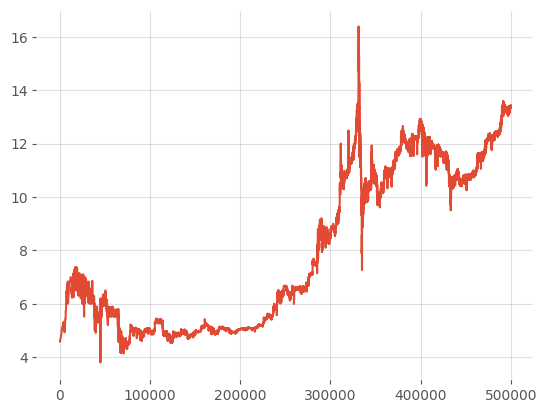

In [79]:
dataset["Weighted_Price"].plot()

plt.show()

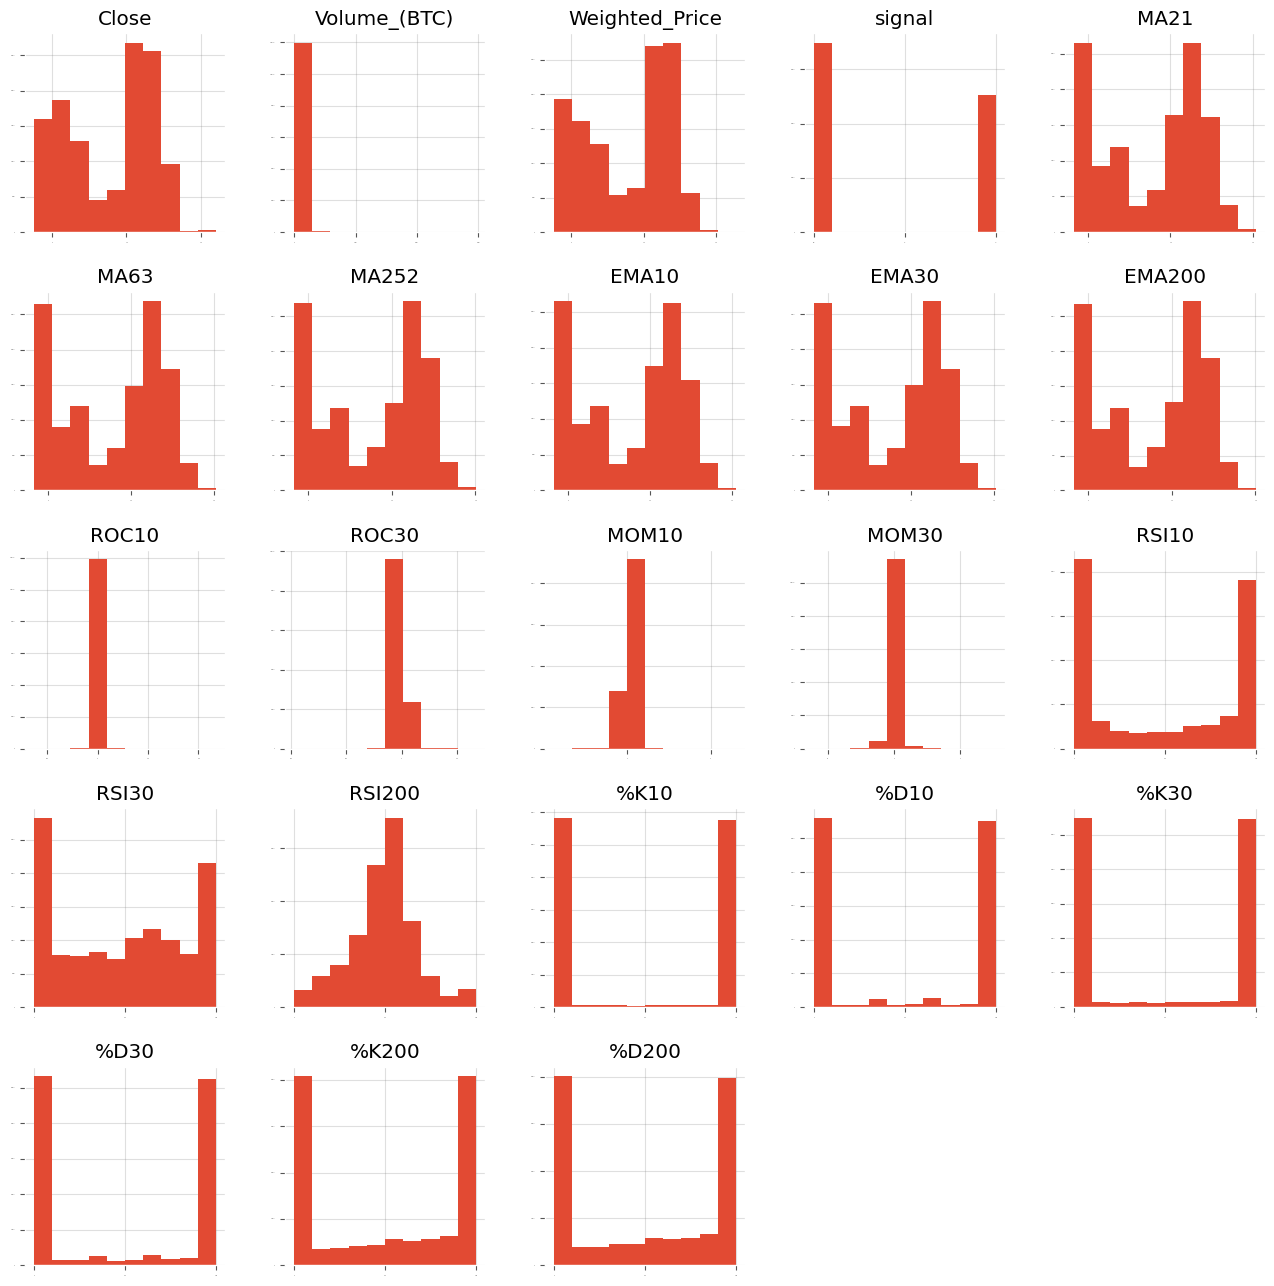

In [80]:
dataset \
    .hist(sharex = False,
          sharey = False,
          xlabelsize = 1,
          ylabelsize = 1,
          figsize = (16, 16)
          )

plt.show()

<Axes: title={'center': 'Correlation Matrix'}>

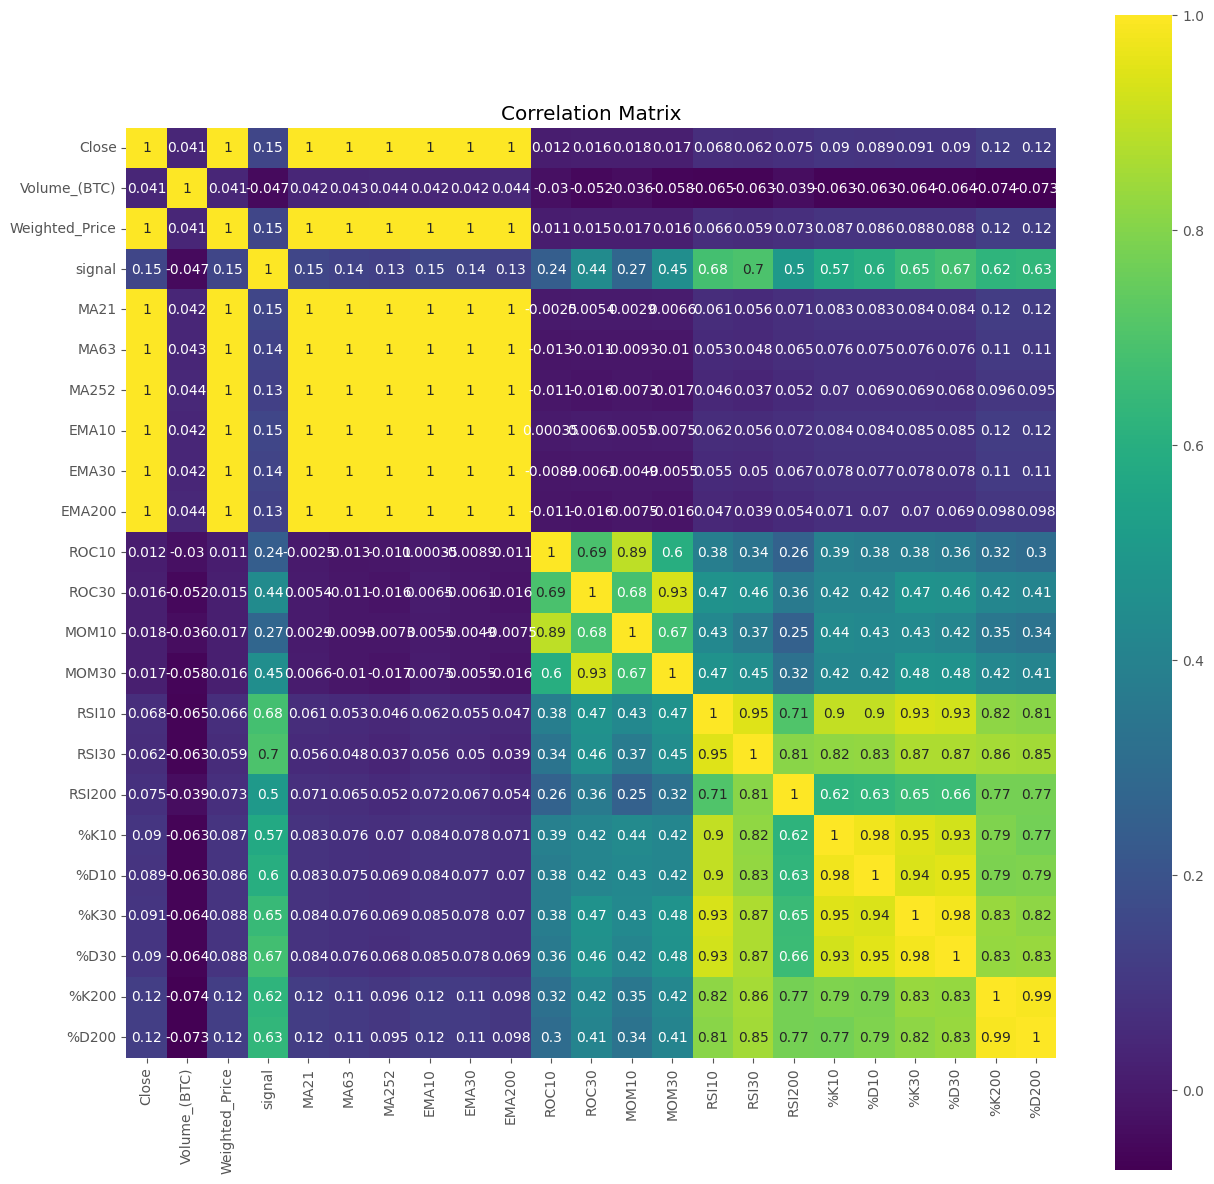

In [81]:
# Correlation matrix
correlation = dataset.corr()

plt.figure(figsize=(15,15))
plt.title("Correlation Matrix")

sns.heatmap(correlation, 
            vmax = 1, 
            square = True,
            annot = True,
            cmap = "viridis")

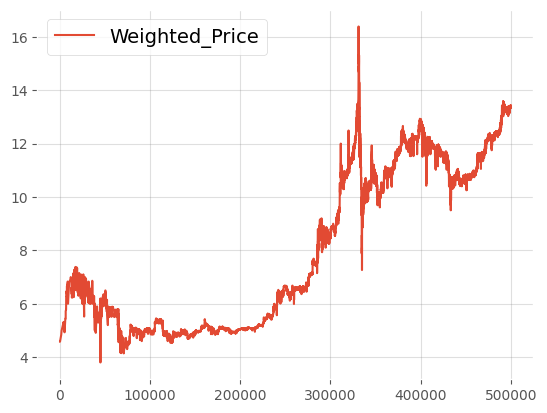

In [82]:
dataset[["Weighted_Price"]].plot(grid = True)

plt.show()

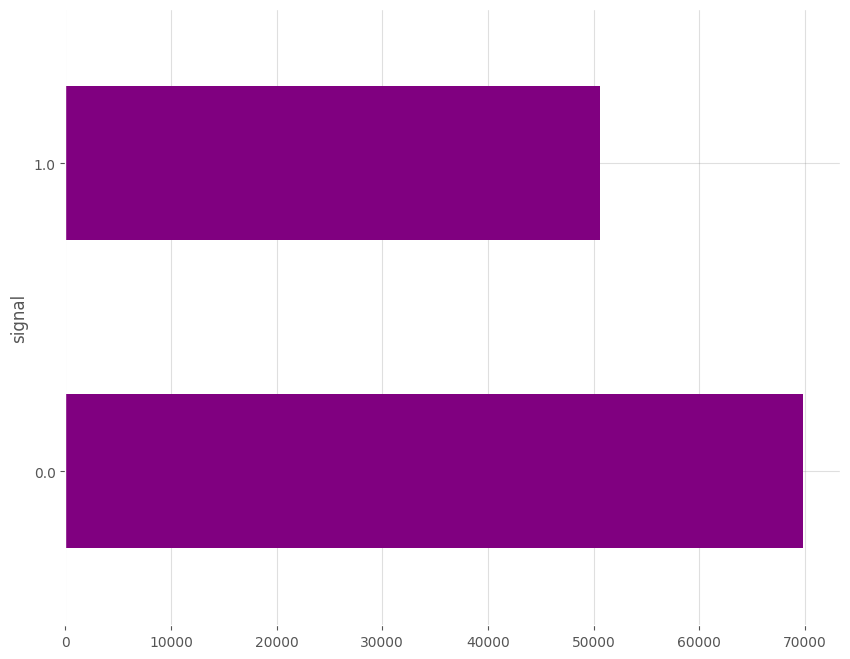

In [ ]:
fig = plt.figure(figsize = (10, 8)
                )
plot = dataset.groupby(["signal"]).size().plot(kind = "barh", 
                                               color = "purple")
plt.show()

<!-- The predicted variable is upward 52.87% out of total data-size, meaning that number
of the buy signals was higher than that of sell signals. -->

## MODEL

### Data Split

> We split the dataset into 80% training set and 20% test set.

In [84]:
subset_dataset= dataset.iloc[-10000:]

In [85]:
Y= subset_dataset["signal"]
X = subset_dataset.loc[:, dataset.columns != "signal"]
validation_size = 0.2
seed = 1

X_train, X_validation, Y_train, Y_validation =\
    train_test_split(X, Y, test_size = validation_size, random_state = 1)

### Feature Extraction

> As a preprocessing step, let's start with normalizing the feature values so they standardised - this makes comparisons simpler and allows next steps for Singular Value Decomposition.

In [87]:
from sklearn.preprocessing import StandardScaler

In [88]:
scaler = StandardScaler().fit(X_train)
rescaledDataset = pd.DataFrame(scaler.fit_transform(X_train),columns = X_train.columns, index = X_train.index)

In [89]:
# summarize transformed data
X_train.dropna(how = "any", inplace = True)
rescaledDataset.dropna(how = "any", inplace = True)
rescaledDataset.head(2)

,Close,Volume_(BTC),Weighted_Price,MA21,MA63,MA252,EMA10,EMA30,EMA200,ROC10,...,MOM30,RSI10,RSI30,RSI200,%K10,%D10,%K30,%D30,%K200,%D200
476354,-0.259388,-0.141336,-0.270337,-0.259731,-0.270488,-0.325730,-0.261348,-0.269534,-0.319807,0.093590,...,0.099035,1.153413,1.538852,1.176925,0.896107,0.931163,0.927165,0.957289,0.991519,1.010912
484333,-0.259388,-0.307013,-0.261688,-0.266476,-0.317838,-0.281444,-0.272437,-0.305710,-0.289282,0.576574,...,0.490092,1.153076,1.451499,-0.105040,0.896107,0.931163,0.927165,0.957289,0.267606,0.276903


### Singular Value Decomposition for Feature Extraction

We want to reduce the dimensionality of the problem to make it more manageable, but at the same time we want to preserve as much information as possible. 

Hence, we use a technique called singu‐
lar value decomposition (SVD), which is one of the ways of performing PCA.Singular Value Decomposition (SVD) is a matrix factorization commonly used in signal processing and data compression. We are using the TruncatedSVD method in the sklearn package.

In [90]:
from matplotlib.ticker import MaxNLocator

Variance preserved by first 5 components == 94.24%


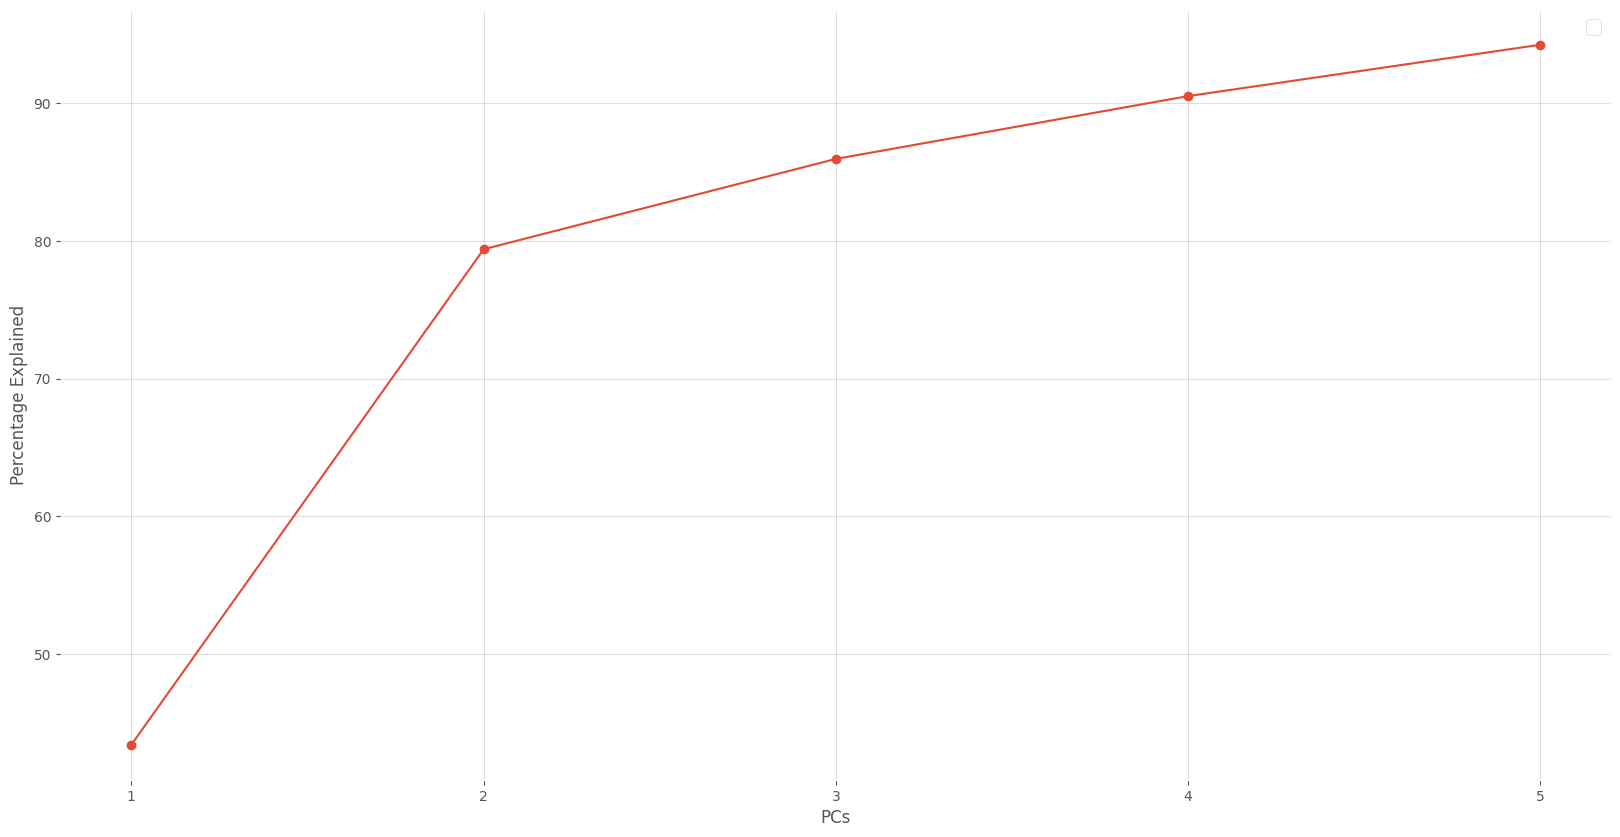

In [91]:
ncomps = 5

svd = TruncatedSVD(n_components=ncomps)

svd_fit = svd.fit(rescaledDataset)

plt_data = pd.DataFrame(svd_fit.explained_variance_ratio_.cumsum()*100)

plt_data.index = np.arange(1, len(plt_data) + 1)

Y_pred = svd.fit_transform(rescaledDataset)

ax = plt_data.plot(kind="line", figsize=(20, 10), style = "o-"
                  )
ax.xaxis.set_major_locator(MaxNLocator(integer = True)
                          )

ax.set_xlabel("PCs")
ax.set_ylabel("Percentage Explained")
ax.legend("")

print("Variance preserved by first 5 components == {:.2%}".format(svd_fit.explained_variance_ratio_.cumsum()[-1]
                                                                 )
     )

We can preserve 92.75% variance by using just 5 components rather than the full 25+ original features.

In [92]:
dfsvd = pd.DataFrame(Y_pred, columns=["pc{}".format(c) for c in range(ncomps)], 
                     index = rescaledDataset.index)
print(dfsvd.shape)
dfsvd.head()

(8000, 5)


,pc0,pc1,pc2,pc3,pc4
476354,2.674587,-1.341726,-1.344262,0.338530,-0.006133
484333,2.331924,-1.302953,0.072249,0.233397,-0.647546
476100,0.276471,-1.362488,0.389544,0.265767,-1.067291
478974,1.541034,-2.814629,-0.923737,0.188644,-0.556339
491284,3.786058,2.949966,-0.024293,1.769701,1.225966


## Compare Models with and without Dimensionality Reduction

In [93]:
# test options for classification
scoring = "accuracy"
seed = 627
kfold = 10

### Model without Dimensionality Reduction

In [94]:
dfsvd

,pc0,pc1,pc2,pc3,pc4
476354,2.674587,-1.341726,-1.344262,0.338530,-0.006133
484333,2.331924,-1.302953,0.072249,0.233397,-0.647546
476100,0.276471,-1.362488,0.389544,0.265767,-1.067291
478974,1.541034,-2.814629,-0.923737,0.188644,-0.556339
491284,3.786058,2.949966,-0.024293,1.769701,1.225966
...,...,...,...,...,...
477018,-1.579906,-1.208935,-0.098262,-0.859209,0.708888
491910,-2.414871,4.638479,0.136039,1.105124,-0.329567
470760,-4.599853,-3.284668,0.851026,-0.660736,0.006693
484457,2.952029,-1.536480,0.040449,0.090400,-0.164958


In [95]:
print("Result without dimensionality Reduction: %f (%f)" % (cv_results_XTrain.mean(), cv_results_XTrain.std()
                                                           )
     )
print("Result with dimensionality Reduction (Yay~): %f (%f)" % (cv_results_SVD.mean(), cv_results_SVD.std()
                                                        )
     )

NameError: name 'cv_results_XTrain' is not defined

## Things to Note

> In terms of the evaluation metrics for a classification-based trading strategy, accuracy or AUC are appropriate. But if the strategy required is greater focus on accuracy while going long, the metric recall which focuses on fewer false positives is preferable to a focus on accuracy.

> Finally, we demonstrated the backtesting framework which allows us to simulate a trading strategy using historical data to generate results and analyse risk and profitability before risking any actual capital.

> We demonstrated that both SVD and t-SNE provide quite an interesting way of visualizing the trading signal data, and provide a way to distinguish long and short signals of a trading strategy with a reduced number of features.

> `Thank you for working with the script, Team 👍`